# **HW2: Linear Algebra and Probability Using NumPy**

#### **Attention:** *This assignment is to be completed individually. Group work is not permitted.*

### **TODO: Please Write Your Full name Here**




In this assignment, you'll apply concepts from linear algebra and probability. Please import all necessary libraries and your dataset before beginning.

In [ ]:
# Import the libraries here.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## **Linear Algebra Using the USA Housing Dataset**

**Load the Dataset: Read the dataset `USA_Housing.csv` into a pandas dataframe.**

In [ ]:
# Write your code here
df = pd.read_csv('USA_Housing.csv', index_col = False)

#### **Question 1**
Create a matrix \( M \) consisting of the first 5 numerical columns of the dataset. Print its dimensions.

In [82]:
# Write your code here
first_five_numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()[:5]
M = np.array(df[first_five_numerical_columns]) # M is the matrix
M.shape


(5000, 5)

#### **Question 2**
Compute the rank of matrix \( M \).

In [ ]:
# Write your code here
rank_matrix = np.linalg.matrix_rank(df[first_five_numerical_columns].dropna())
print(f'There are {rank_matrix} linearly independent columsn/rows')

There are 5 linearly independent columsn/rows


#### **Question 3**
Extract the `Price` column as a vector \( p \). Compute the dot product of the matrix \( M \) (transposed) and vector \( p \). What does this represent (write 1-2 sentences)?

In [ ]:
# Write your code here
p = np.array(df['Price']) # Price column vector
matrix_product = M.T @ p
print(matrix_product)

[4.34532727e+14 3.76138778e+10 4.36433193e+10 2.48991246e+10
 2.29938746e+14]


**TODO: This product represents the cost of living for each housing area**

## **Probability**

#### **Question 4**
Suppose houses are classified as "High-Price" if their prices are above the 90th percentile of all house prices in the dataset. What is the probability that a randomly selected house from the dataset is "High-Price"?

Here's how you can solve this using NumPy:

* Calculate the 90th percentile price.
* Count the number of houses with prices above this value.
* Divide this count by the total number of houses to get the probability.

In [ ]:
# Write your code here

percentile_90_price = np.percentile(df['Price'].dropna(), 90)


high_price_count = np.sum(df['Price'] > percentile_90_price)

# Compute the probability
probability_high_price = high_price_count / len(df.dropna(subset=['Price']))

print(f"90th Percentile Price: ${percentile_90_price:.2f}")
print(f"Number of High-Price Houses: {high_price_count}")
print(f"Probability of a House Being High-Price: {probability_high_price:.4f}")


# The probability value of 0.1000 (or  10 %) indicates that there is a
# 10% chance that a randomly selected house from the dataset will be classified as "High-Price".

90th Percentile Price: $1684620.95
Number of High-Price Houses: 500
Probability of a House Being High-Price: 0.1000


#### **Question 5**
Compute the correlation between `Avg. Area Income` and `Price`. Also, write in 1-2 sentences below your code cell about what you infer from this correlation value.

PS: You can use `corr()` method here.

In [ ]:
# Write your code here
correlation_income_price = df[['Avg. Area Income', 'Price']].corr()
print(f"Correlation between 'Avg. Area Income' and 'Price': {correlation_income_price}")

Correlation between 'Avg. Area Income' and 'Price':                   Avg. Area Income     Price
Avg. Area Income          1.000000  0.639734
Price                     0.639734  1.000000


**TODO: There is a moderately strong positive correlation between the Avg. Area Income and Price which suggests that the more income a family makes, the higher price/cost will be.**

## **Visualization**

* All plots should have a title and appropriate labels.

#### **Question 6**
Generate a histogram for `Avg. Area House Age`. Describe its distribution in 1-2 sentences.

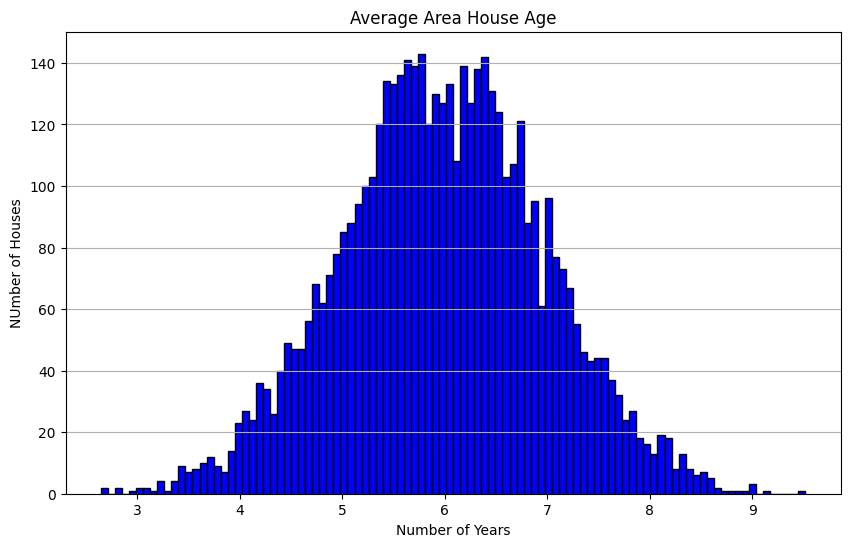

In [ ]:
# Write your code here
plt.figure(figsize=(10,6))
plt.hist(df['Avg. Area House Age'].dropna(), bins=100, color='blue', edgecolor='black')
plt.title('Average Area House Age')
plt.xlabel('Number of Years')
plt.ylabel('NUmber of Houses')
plt.grid(True, axis='y')
plt.show()

**TODO: A mojority of houses that are built in the area are between 5 to 7 years old.**

#### **Question 7**
Generate a scatter plot between `Avg. Area Income` and `Price`. What does the relationship look like (write 1-2 sentences)?

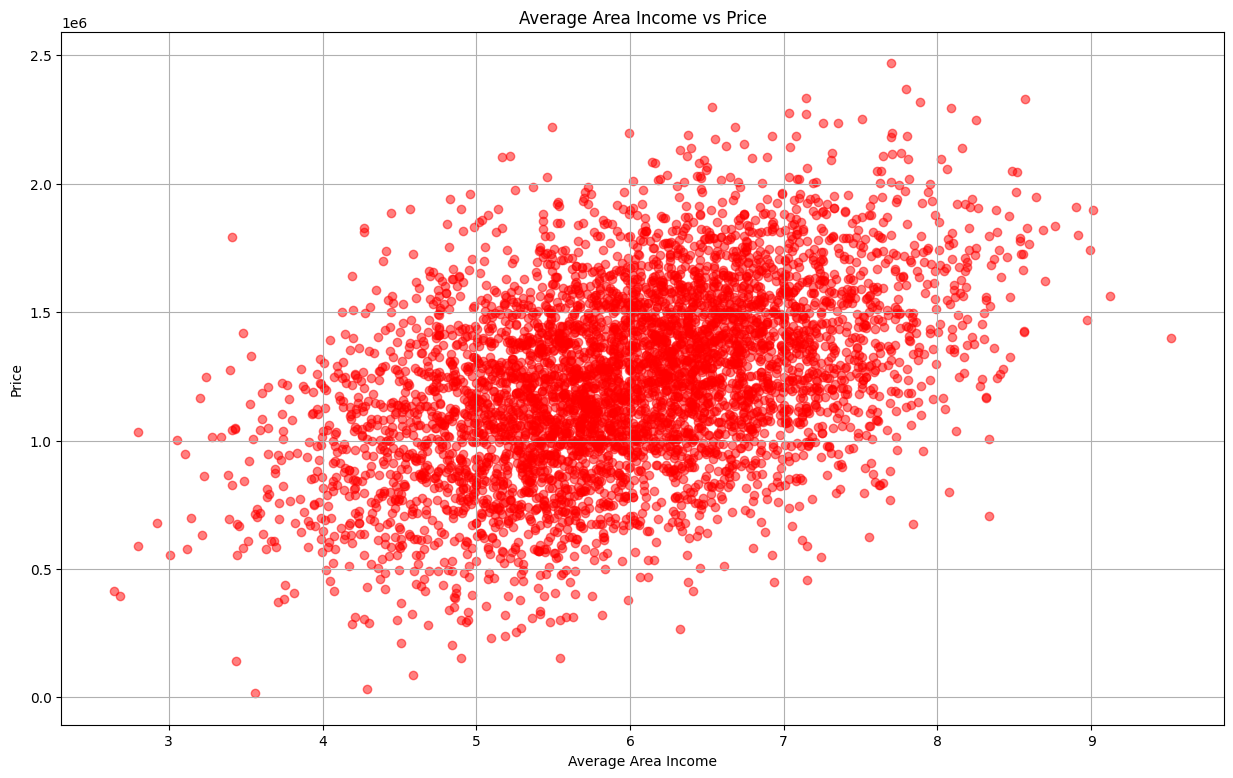

In [ ]:
# Write your code here
plt.figure(figsize=(15,9))
plt.scatter(df['Avg. Area House Age'], df['Price'], alpha=0.5, color='red')
plt.title('Average Area Income vs Price')
plt.xlabel('Average Area Income')
plt.ylabel('Price')
plt.grid()
plt.show()

**TODO: Average area income and house prices show a postive upward relationship which suggests a linear relationship**

### **Question 8**

Plot a heatmap showing the correlation between the numerical columns in the dataset. Which two factors have the highest correlation with the 'Price'?

You can choose to use either `seaborn` or `matplotlib` here.

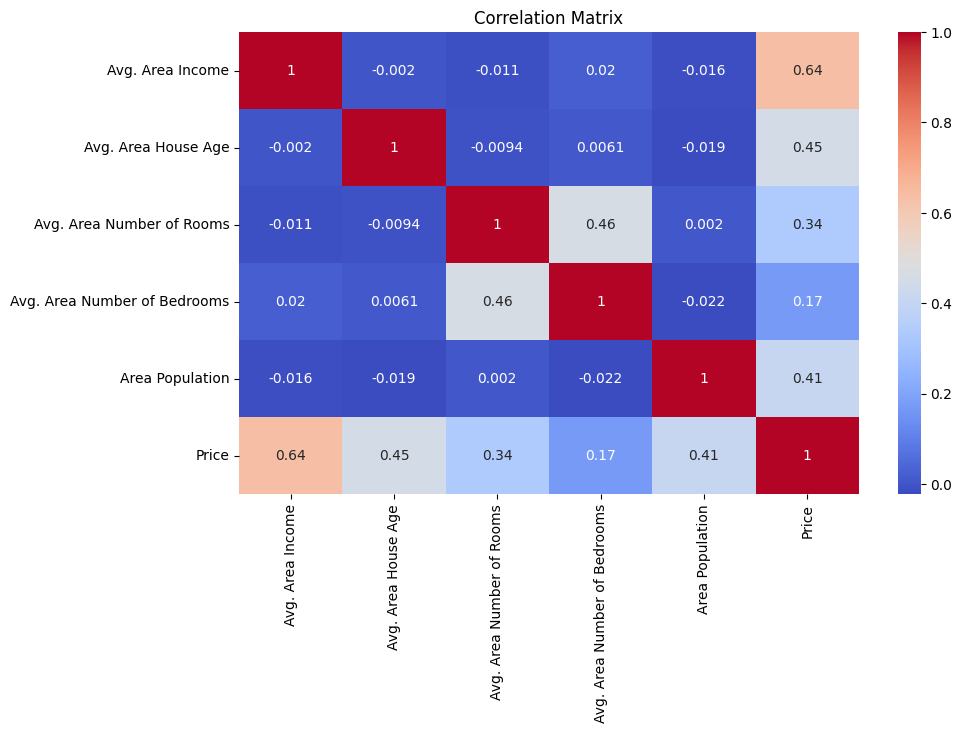

In [ ]:
# Write your code here
import seaborn as sns

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = np.corrcoef(df[numerical_columns].dropna().values, rowvar=False)

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', xticklabels=numerical_columns, yticklabels=numerical_columns)
plt.title('Correlation Matrix')
plt.show()

**TODO: 'Avg. Area Income' and 'Avg. Area Home Age' have the highest correlation with Price being 0.64 and 0.45, respectively.**